# AKLS Historical SSM with auxiliary filtrate antibody observations

このNotebookは、前段Propagation/SSMの出力に接続するHistorical Modelを、状態空間モデル(State Space Model, SSM)として2案実装する。

## 全体の位置づけ（データはどこから来て、何を予測するか）

```text
[前段Notebook] akls_small_ssm_pymc_interactive.ipynb
   -> 出力: akls_small_ssm_pymc_predictions.csv
      (各runの時系列ごとに、fouling state / TMP予測 / transmission予測などを含む)
        |
        v
[本Notebook] akls_historical_ssm_auxiliary_A_B.ipynb
   -> 前段の予測値を「説明変数」として読み込み、
      最終的な目的変数である filtrate antibody concentration (g/L)、
      および累積回収量 proxy を、案A/案Bの2通りのモデルで予測する
```

つまり、本Notebookは新たに実験データを解析するのではなく、**前段モデルの結果を土台にして、より下流の最終目的変数（フィルトレート中の抗体濃度、累積回収量）を予測する「二段階目」のモデル**である。前段が未実行の場合は、生データ(`AKLS_master_dataset.xlsx`など)から簡易的な代替特徴量を作ってフォールバックする。

## 案A: Effective sieving SSM

潜在状態を `S_t = effective sieving / transmission fraction`（膜を抗体がどれだけ通過しやすいか、を0〜1で表す指標）とし、logitスケールで時間とともに低下するモデルである。

```text
z_t = logit(S_t)
z_t = z0_run - cumulative_degradation_t
filtrate_antibody_t ~ feed_antibody_t * sigmoid(z_t)
```

途中の `filtrate_antibody_g_l`（実測されたフィルトレート抗体濃度）を補助観測として尤度に入れる。Transmissionを同時に尤度へ入れると二重カウントになりやすいため、デフォルトでは使用しない。

## 案B: Cumulative recovery / quality SSM

案Aの `S_t` を使って、累積回収状態 `Q_t`（濾過開始からの累積抗体回収量に近いproxy）を作る。

```text
Q_t = Q_{t-1} + feed_antibody_t * S_t * delta_cumulative_filtrate_t
```

`Q_t` は、濃度ではなく、累積透過/回収された抗体量の proxy である。最終累積回収量がデータにあれば尤度に入れられる。ない場合はfiltrate antibody観測から診断用のproxyを作る。

## 使い方

1. 前段 `akls_small_ssm_pymc_interactive.ipynb` を実行し、`akls_small_ssm_pymc_predictions.csv` を作る
2. このNotebookを `Restart Kernel` -> `Run All` で実行する
3. `RUN_MODEL_A` / `RUN_MODEL_B` や `RUN_SAMPLING` を必要に応じて切り替える

run数が少ないため、係数は強めに縮小し、モデルは意図的に小さくしている。


In [2]:
# このセルでは、依存ライブラリ、入出力パス、案A/Bの実行設定を準備する。
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as _norm

# 日本語ラベルを図に正しく表示するための設定。無くても動くが文字化けする可能性がある。
try:
    import japanize_matplotlib  # noqa: F401
except Exception:
    pass

# ベイズ推定(MCMC)に使うPyMCスタック。未インストール環境でもNotebook自体は最後まで実行できるようにフォールバックする。
try:
    import arviz as az
    import pymc as pm
    import pytensor.tensor as pt
    PYMC_AVAILABLE = True
except Exception as exc:
    az = None
    pm = None
    pt = None
    PYMC_AVAILABLE = False
    print(f"PyMC/ArviZ/PyTensor is not available: {exc}")

# numpyroが使えるとPyMCのNUTSサンプラーが高速化されるため、あれば自動的に使う。
try:
    import numpyro  # noqa: F401
    NUMPYRO_AVAILABLE = True
except Exception:
    NUMPYRO_AVAILABLE = False

np.random.seed(42)
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 120)
np.set_printoptions(suppress=True, precision=4)

# 実行環境（ローカル/コンテナ）によって作業ディレクトリが異なるため、
# 候補パスを順に確認して、入出力に使う BASE_DIR を自動判定する。
path_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "CVC" / "AKLS",
    Path.cwd().parent / "AKLS",
    Path("/workspace"),
]
BASE_DIR = next((p for p in path_candidates if (p / "user_files").exists() or (p / "akls_pymc_interactive_results").exists()), Path.cwd())
PROPAGATION_OUTPUT_DIR = BASE_DIR / "akls_pymc_interactive_results"
OUTPUT_DIR = BASE_DIR / "akls_historical_ssm_auxiliary_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 前段Propagation/SSMの予測CSVを最優先の入力とし、無ければ生データにフォールバックする。
prediction_candidates = [
    PROPAGATION_OUTPUT_DIR / "akls_small_ssm_pymc_predictions.csv",
    BASE_DIR / "akls_small_ssm_pymc_predictions.csv",
    BASE_DIR / "output" / "akls_small_ssm_pymc_predictions.csv",
]
raw_candidates = [
    BASE_DIR / "user_files" / "AKLS_master_dataset.xlsx",
    BASE_DIR / "AKLS_master_dataset.xlsx",
    BASE_DIR / "AKLS_cleaned_records.csv",
    BASE_DIR / "output" / "AKLS_cleaned_records.csv",
]

PREDICTIONS_PATH = next((p for p in prediction_candidates if p.exists()), None)
RAW_DATA_PATH = next((p for p in raw_candidates if p.exists()), None)

# --- 実行スイッチ ---
# RUN_MODEL_A / RUN_MODEL_B: 案A（濃度予測のみ）/ 案B（濃度＋累積回収量）をそれぞれ実行するか
# RUN_SAMPLING: Falseにすると、モデルの構築だけ行いMCMCサンプリングはスキップする（動作確認用）
RUN_MODEL_A = True
RUN_MODEL_B = True
RUN_SAMPLING = True
DRAWS = 800
TUNE = 800
CHAINS = 4
CORES = min(CHAINS, 4)
TARGET_ACCEPT = 0.92
RANDOM_SEED = 42
HDI_PROB = 0.90
# Transmission実測値を尤度に追加するか。filtrate antibody濃度と二重カウントになりやすいため既定はFalse。
USE_TRANSMISSION_AUX_LIKELIHOOD = False
# 最終時点の累積回収量(proxy)を尤度に追加するか（案Bのみ関係）。
USE_FINAL_CUMULATIVE_RECOVERY_LIKELIHOOD = True
# 前段Propagation/SSMのfouling/TMP予測を点推定(固定値)ではなく、その不確実性(HDI幅)を
# sigmaとして持つ潜在変数として扱うか（測定誤差モデル）。Falseなら従来通り固定値として扱う。
USE_PROPAGATION_UNCERTAINTY = True
# 前段予測CSVの`_lower`/`_upper`列が表すHDIの確率（前段Notebookの既定値と合わせる）。
HDI_PROB_PROPAGATION = 0.90

print(f"BASE_DIR={BASE_DIR}")
print(f"PREDICTIONS_PATH={PREDICTIONS_PATH}")
print(f"RAW_DATA_PATH={RAW_DATA_PATH}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")
print(f"PYMC_AVAILABLE={PYMC_AVAILABLE}, NUMPYRO_AVAILABLE={NUMPYRO_AVAILABLE}")
print(f"RUN_MODEL_A={RUN_MODEL_A}, RUN_MODEL_B={RUN_MODEL_B}, RUN_SAMPLING={RUN_SAMPLING}")
print(f"USE_PROPAGATION_UNCERTAINTY={USE_PROPAGATION_UNCERTAINTY}, HDI_PROB_PROPAGATION={HDI_PROB_PROPAGATION}")


BASE_DIR=d:\Users\a1049994\CVC\AKLS
PREDICTIONS_PATH=d:\Users\a1049994\CVC\AKLS\akls_pymc_interactive_results\akls_small_ssm_pymc_predictions.csv
RAW_DATA_PATH=d:\Users\a1049994\CVC\AKLS\user_files\AKLS_master_dataset.xlsx
OUTPUT_DIR=d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results
PYMC_AVAILABLE=True, NUMPYRO_AVAILABLE=True
RUN_MODEL_A=True, RUN_MODEL_B=True, RUN_SAMPLING=True
USE_PROPAGATION_UNCERTAINTY=True, HDI_PROB_PROPAGATION=0.9


## 1. 入力データ読み込みとcanonical schema化

前段Propagation/SSMの予測CSVがあればそれを優先する。ない場合は、整形済み観測CSVからfallback特徴量を作る。

- 読み込んだ生データは列名の表記ゆれ（大文字/小文字、単位表記など）が多いため、以降の処理で一貫して使えるように列名を統一（canonical schema化）する
- `run_id` は実験run（バッチ）を識別するキーであり、以降のすべての集計・モデル化はrun単位で行う


In [3]:
# このセルでは、Excel/CSVを読み込み、列名とrun識別子をcanonical schemaへ正規化する。
# 前段Propagation/SSMの予測CSVを優先し、未実行時はrawデータへfallbackする。
def read_table(path: Path) -> pd.DataFrame:
    # Excel系はシート名固定（Master_Data）、それ以外はCSVとして読む
    path = Path(path)
    if path.suffix.lower() in {".xlsx", ".xlsm", ".xls"}:
        return pd.read_excel(path, sheet_name="Master_Data")
    return pd.read_csv(path)


def normalize_columns(frame: pd.DataFrame) -> pd.DataFrame:
    # 表記ゆれのある列名を、以降のコードで使うスネークケース名へ統一する対応表
    aliases = {
        "tmp_kPa": "tmp_kpa", "TMP_kPa": "tmp_kpa",
        "back_pressure_kPa": "back_pressure_kpa",
        "feed_antibody_g_L": "feed_antibody_g_l",
        "filtrate_antibody_g_L": "filtrate_antibody_g_l",
        "filtration_amount_L_m2": "cumulative_filtrate_l_m2",
        "experiment": "run_id", "lmh_level": "lmh_group",
        "shear_rate": "shear_rate_lmh", "condition": "condition_label",
    }
    out = frame.rename(columns=aliases).copy()
    if "run_id" in out.columns:
        # run_idは数値部分を抽出し2桁ゼロ埋め（例: "Run 3" -> "03"）で表記を揃える
        out["run_id"] = out["run_id"].astype(str).str.extract(r"(\d+)", expand=False).fillna(out["run_id"].astype(str)).str.zfill(2)
    if "condition_label" not in out.columns and "run_id" in out.columns:
        out["condition_label"] = out["run_id"].astype(str)
    if "row_number" not in out.columns and "run_id" in out.columns:
        # run内での時系列順序を保持するための連番（0始まり）
        out["row_number"] = out.groupby("run_id", dropna=False).cumcount()
    return out


def load_timeseries() -> pd.DataFrame:
    # 優先順位: 前段Propagation/SSMの予測CSV > 生データ（フォールバック）
    if PREDICTIONS_PATH is not None:
        df = normalize_columns(read_table(PREDICTIONS_PATH))
        df["data_source"] = "propagation_predictions"
        print(f"Loaded propagation predictions: {PREDICTIONS_PATH}")
        return df
    if RAW_DATA_PATH is not None:
        df = normalize_columns(read_table(RAW_DATA_PATH))
        df["data_source"] = "raw_observed_fallback"
        print("前段予測CSVが見つからないため、観測データからfallback特徴量を作ります。")
        print("本番では先に akls_small_ssm_pymc_interactive.ipynb を実行してください。")
        return df
    raise FileNotFoundError("No propagation prediction CSV or raw AKLS dataset was found.")

ts_raw = load_timeseries()
print(ts_raw.shape)
display(ts_raw.head())
print(sorted(ts_raw.columns))


Loaded propagation predictions: d:\Users\a1049994\CVC\AKLS\akls_pymc_interactive_results\akls_small_ssm_pymc_predictions.csv
(185, 72)


,run_id,record_id,source_file,source_sheet,condition_label,shear_rate_lmh,lmh_group,row_number,sample_label,elapsed_h,sampling_volume_raw,sample_volume_feed_ml,sample_volume_filtrate_ml,circulation_flow_ml_min,circulation_pump_rpm,filtration_flow_ul_min,filtrate_column_cm,filtrate_collection_time_raw,cumulative_filtrate_l_m2,cumulative_flow_ratio_pct,filtration_flow_ratio_pct,pressure_in_kpa,pressure_out_kpa,back_pressure_kpa,tmp_kpa,temperature_c,vcd_cho_1e5_cells_ml,viability_cho_pct,vcd_matsuda_1e5_cells_ml,viability_matsuda_pct,glc_g_l,glu_mmol_l,gln_mmol_l,lln_g_l,feed_antibody_g_l,filtrate_antibody_g_l,transmission_pct,feed_ab_amount_g_m2,filtrate_ab_amount_g_m2,cumulative_transmission_pct,turbidity_feed_od600,turbidity_filtrate_od600,turbidity_plate_reader_od600,ldh_reading_1,ldh_reading_2,ldh_avg,ldh_sd,is_before_start,is_filtration_start,time_from_previous_h,tmp_delta_from_start_kpa,transmission_delta_from_start_pct,filtrate_ab_ratio_to_start,fouling_indicator_simple,cumulative_filtrate_l_m2_interp,back_pressure_kpa_interp,back_pressure_load,feed_antibody_g_l_interp,run_idx,fouling_state_mean,fouling_state_lower,fouling_state_upper,tmp_pred_kpa_mean,tmp_pred_kpa_lower,tmp_pred_kpa_upper,transmission_pred_pct_mean,transmission_pred_pct_lower,transmission_pred_pct_upper,filtrate_antibody_pred_g_l_mean,filtrate_antibody_pred_g_l_lower,filtrate_antibody_pred_g_l_upper,data_source
0,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,5,Filtration start,0.0,NaN,NaN,NaN,8.05,920.0,NaN,NaN,NaN,0.000000,NaN,NaN,1.5,-1.0,-0.4,0.7,9.4,146.0,94.8,NaN,NaN,3.14,0.48,0.32,0.50,0.496091,NaN,NaN,NaN,NaN,NaN,1.225,NaN,NaN,NaN,NaN,NaN,NaN,0,1,NaN,0.0,NaN,NaN,0.000000,0.000000,-0.4,0.4,0.496091,0,0.000000,0.000000,0.000000,0.483935,0.455199,0.512434,98.960754,98.732175,99.170439,0.490935,0.489801,0.491975,propagation_predictions
1,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,6,NaN,2.0,NaN,NaN,NaN,8.05,950.0,NaN,NaN,NaN,NaN,NaN,NaN,1.3,-1.3,-0.8,0.8,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,2.0,0.1,NaN,NaN,0.001000,8.943885,-0.8,0.8,0.495266,0,0.003431,0.001270,0.007652,0.884225,0.855476,0.912711,98.957863,98.728804,99.166979,0.490105,0.488970,0.491141,propagation_predictions
2,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,7,NaN,17.5,NaN,NaN,NaN,8.05,960.0,5.110792,2.3,00:33:58,17.887771,101.693805,NaN,1.4,-1.3,-1.0,1.1,3.6,137.0,93.5,NaN,NaN,3.16,0.50,0.28,0.56,0.494442,0.488015,98.700124,8.859209,8.729494,98.535814,NaN,0.006,NaN,NaN,NaN,NaN,NaN,0,0,15.5,0.4,0.000000,1.000000,0.004000,17.887771,-1.0,1.0,0.494442,0,0.030445,0.011430,0.067589,1.085371,1.057079,1.113444,98.933842,98.707957,99.140203,0.489170,0.488053,0.490191,propagation_predictions
3,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,8,NaN,24.0,NaN,NaN,NaN,8.05,950.0,4.962856,2.0,00:30:25,24.435642,101.295191,NaN,1.3,-1.3,-1.0,1.1,NaN,153.0,94.5,NaN,NaN,3.08,0.50,0.28,0.58,0.495550,0.487018,98.278103,3.241170,3.192192,98.523241,NaN,0.007,NaN,NaN,NaN,NaN,NaN,0,0,6.5,0.4,-0.422021,0.997957,0.008220,24.435642,-1.0,1.0,0.495550,0,0.041932,0.015812,0.093132,1.085848,1.057713,1.113789,98.922924,98.698022,99.129558,0.490213,0.489098,0.491237,propagation_predictions
4,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,9,NaN,42.5,NaN,NaN,NaN,8.05,960.0,5.086035,2.5,00:37:06,43.026090,100.720825,NaN,1.4,-1.3,-1.0,1.1,3.3,150.0,94.3,NaN,NaN,2.98,0.48,0.28,0.60,0.493589,0.486432,98.549982,9.194275,9.048433,98.475977,NaN,0.006,NaN,NaN,NaN,NaN,NaN,0,0,18.5,0.4,-0.150142,0.996757,0.005501,43.026090,-1.0,1.0,0.493589,0,0.075378,0.028749,0.166666,1.087315,1.059795,1.114827,98.888512,98.667123,99.093006,0.488103,0.487010,0.489112,propagation_predictions


['back_pressure_kpa', 'back_pressure_kpa_interp', 'back_pressure_load', 'circulation_flow_ml_min', 'circulation_pump_rpm', 'condition_label', 'cumulative_filtrate_l_m2', 'cumulative_filtrate_l_m2_interp', 'cumulative_flow_ratio_pct', 'cumulative_transmission_pct', 'data_source', 'elapsed_h', 'feed_ab_amount_g_m2', 'feed_antibody_g_l', 'feed_antibody_g_l_interp', 'filtrate_ab_amount_g_m2', 'filtrate_ab_ratio_to_start', 'filtrate_antibody_g_l', 'filtrate_antibody_pred_g_l_lower', 'filtrate_antibody_pred_g_l_mean', 'filtrate_antibody_pred_g_l_upper', 'filtrate_collection_time_raw', 'filtrate_column_cm', 'filtration_flow_ratio_pct', 'filtration_flow_ul_min', 'fouling_indicator_simple', 'fouling_state_lower', 'fouling_state_mean', 'fouling_state_upper', 'glc_g_l', 'gln_mmol_l', 'glu_mmol_l', 'is_before_start', 'is_filtration_start', 'ldh_avg', 'ldh_reading_1', 'ldh_reading_2', 'ldh_sd', 'lln_g_l', 'lmh_group', 'pressure_in_kpa', 'pressure_out_kpa', 'record_id', 'row_number', 'run_id', 'run_

## 2. Historical SSM用の時系列配列を作る

案A・案Bで共通に使う配列を作る。状態空間モデルでは「ある時点の状態＝直前の状態＋その間の変化量の積み上げ」という形で表現するため、ここでは各runの観測を時系列順に並べ、時点間の「遷移（transition）」ごとの変化量を計算しておく。

- `A_hist`: 過去の劣化増分を各時点へ累積する行列（各観測時点までに、どの遷移の増分を足し合わせるかを表す0/1行列）
- `F_t`: 前段Propagation/SSMのfouling state（膜の目詰まり状態、大きいほど劣化が進んでいる）
- `TMP_t`: 前段予測TMP（膜間差圧）または観測TMP
- `feed_t`: feed抗体濃度（膜に入る前の抗体濃度）
- `filtrate_obs_t`: 補助観測として使うfiltrate抗体濃度（膜を通過した後の実測抗体濃度）
- `delta_cum_l_m2`: 累積ろ過量の区間増分（案Bの累積回収量計算に使用）
- `F_mid_sigma_std` / `tmp_mid_sigma_std`: 前段予測の `_lower`/`_upper`(90%HDI)幅から近似したsigma。`USE_PROPAGATION_UNCERTAINTY=True` のとき、`F_t`・`TMP_t` を固定値ではなく測定誤差付きの潜在変数として扱うために使う（詳細は案A節を参照）


In [4]:
# このセルでは、run別の時系列を整形し、案A/Bが共有する遷移配列と観測proxyを作成する。
def logit_np(x: np.ndarray) -> np.ndarray:
    # 0〜1の割合をlogitスケール(-∞〜∞)へ変換。0/1ちょうどは数値的に不安定なため微小値でクリップする
    x = np.clip(np.asarray(x, dtype=float), 1e-6, 1.0 - 1e-6)
    return np.log(x / (1.0 - x))


def sigmoid_np(x: np.ndarray) -> np.ndarray:
    # logitの逆変換。モデル内部のlogitスケール状態を0〜1の割合へ戻すときに使う
    return 1.0 / (1.0 + np.exp(-x))


def safe_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    # 指定列を数値型へ変換し、変換できない値はNaNにする（文字列混入への防御）
    out = frame.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def standardize(values: np.ndarray) -> tuple[np.ndarray, float, float]:
    # モデルの事前分布・収束を安定させるため、説明変数を平均0・標準偏差1に標準化する
    values = np.asarray(values, dtype=float)
    mean = np.nanmean(values)
    sd = np.nanstd(values)
    if not np.isfinite(sd) or sd == 0:
        sd = 1.0
    return (values - mean) / sd, float(mean), float(sd)


def interpolate_by_run(frame: pd.DataFrame, column: str, fill_value: float | None = None) -> pd.Series:
    # 欠測値をrunごとに時系列補間する（run間で値を混ぜないようにgroupby("run_id")で区切る）
    if column not in frame.columns:
        return pd.Series(np.nan, index=frame.index, dtype=float)
    series = frame.groupby("run_id")[column].transform(lambda s: s.interpolate(limit_direction="both"))
    if fill_value is not None:
        series = series.fillna(fill_value)
    return series


def ensure_model_columns(frame: pd.DataFrame) -> pd.DataFrame:
    # モデルが必要とする列を揃える。前段予測CSVが無い場合は簡易的な代替値を作ってフォールバックする。
    work = frame.copy()
    numeric_cols = [
        "elapsed_h", "row_number", "tmp_kpa", "tmp_pred_kpa_mean", "transmission_pct",
        "transmission_pred_pct_mean", "filtrate_antibody_g_l", "feed_antibody_g_l",
        "fouling_state_mean", "cumulative_filtrate_l_m2", "back_pressure_kpa",
        "lmh_group", "shear_rate_lmh",
        "fouling_state_lower", "fouling_state_upper",
        "tmp_pred_kpa_lower", "tmp_pred_kpa_upper",
    ]
    work = safe_numeric(work, numeric_cols)

    # 前段予測CSVがない場合のfallback。
    if "tmp_pred_kpa_mean" not in work.columns:
        work["tmp_pred_kpa_mean"] = work.get("tmp_kpa", np.nan)
    if "fouling_state_mean" not in work.columns:
        if "cumulative_filtrate_l_m2" in work.columns:
            work["fouling_state_mean"] = pd.to_numeric(work["cumulative_filtrate_l_m2"], errors="coerce") / 500.0
        else:
            work["fouling_state_mean"] = np.nan
    if "transmission_pred_pct_mean" not in work.columns:
        work["transmission_pred_pct_mean"] = work.get("transmission_pct", np.nan)

    required = ["run_id", "elapsed_h", "feed_antibody_g_l", "filtrate_antibody_g_l"]
    missing = [col for col in required if col not in work.columns]
    if missing:
        raise ValueError(f"Missing required columns for historical SSM: {missing}")

    # 前段予測の`_lower`/`_upper`(HDI)からsigmaを近似する（測定誤差モデル用）。
    # 正規分布を仮定し、両側HDI幅から標準偏差を逆算する: sigma = (upper - lower) / (2 * z)。
    # `_lower`/`_upper`が無い場合（rawデータのfallback時など）はsigma=0とし、事実上の固定値として扱う。
    z_score = float(_norm.ppf(0.5 + HDI_PROB_PROPAGATION / 2.0))
    if "fouling_state_lower" in work.columns and "fouling_state_upper" in work.columns:
        work["fouling_state_sigma"] = ((work["fouling_state_upper"] - work["fouling_state_lower"]) / (2.0 * z_score)).clip(lower=0.0).fillna(0.0)
    else:
        work["fouling_state_sigma"] = 0.0
    if "tmp_pred_kpa_lower" in work.columns and "tmp_pred_kpa_upper" in work.columns:
        work["tmp_pred_kpa_sigma"] = ((work["tmp_pred_kpa_upper"] - work["tmp_pred_kpa_lower"]) / (2.0 * z_score)).clip(lower=0.0).fillna(0.0)
    else:
        work["tmp_pred_kpa_sigma"] = 0.0

    # run・経過時間順にソートし、run内で欠測を補間、後続処理で使う派生列を作る
    work = work.loc[work["run_id"].notna() & work["elapsed_h"].notna()].copy()
    work = work.sort_values(["run_id", "elapsed_h", "row_number"]).reset_index(drop=True)
    work["feed_antibody_interp"] = interpolate_by_run(work, "feed_antibody_g_l")
    work["filtrate_antibody_interp"] = interpolate_by_run(work, "filtrate_antibody_g_l")
    work["fouling_state_interp"] = interpolate_by_run(work, "fouling_state_mean", fill_value=0.0)
    work["fouling_state_sigma_interp"] = interpolate_by_run(work, "fouling_state_sigma", fill_value=0.0)
    work["tmp_pred_interp"] = interpolate_by_run(work, "tmp_pred_kpa_mean")
    work["tmp_pred_sigma_interp"] = interpolate_by_run(work, "tmp_pred_kpa_sigma", fill_value=0.0)
    work["transmission_obs_fraction"] = np.clip(pd.to_numeric(work.get("transmission_pct", np.nan), errors="coerce") / 100.0, 0.005, 0.995)
    work["high_load"] = (pd.to_numeric(work.get("lmh_group", np.nan), errors="coerce") == 10).astype(float)
    work["cumulative_filtrate_interp"] = interpolate_by_run(work, "cumulative_filtrate_l_m2", fill_value=0.0)
    return work


def build_hist_ssm_arrays(frame: pd.DataFrame) -> dict:
    # run一覧を、負荷条件（lmh_group）・shear条件・run_idの順で並べ替え、モデル内で使うインデックスを割り当てる
    work = ensure_model_columns(frame)
    runs = sorted(work["run_id"].dropna().unique(), key=lambda run: (
        int(pd.to_numeric(work.loc[work["run_id"] == run, "lmh_group"].dropna().iloc[0], errors="coerce")) if work.loc[work["run_id"] == run, "lmh_group"].notna().any() else 0,
        int(pd.to_numeric(work.loc[work["run_id"] == run, "shear_rate_lmh"].dropna().iloc[0], errors="coerce")) if work.loc[work["run_id"] == run, "shear_rate_lmh"].notna().any() else 0,
        str(run),
    ))
    run_index = {run: i for i, run in enumerate(runs)}
    work["run_idx"] = work["run_id"].map(run_index).astype(int)

    # run内の隣接する観測時点ごとに「遷移」を1件作る。遷移には、時間差・累積ろ過量の増分・
    # 区間中点でのfouling/TMP/高負荷フラグを持たせ、劣化速度の説明変数として使う。
    transitions = []
    for run in runs:
        idx = work.index[work["run_id"] == run].to_numpy()
        if len(idx) < 2:
            continue
        times = work.loc[idx, "elapsed_h"].to_numpy(float)
        cumulative = work.loc[idx, "cumulative_filtrate_interp"].to_numpy(float)
        F = work.loc[idx, "fouling_state_interp"].to_numpy(float)
        F_sigma = work.loc[idx, "fouling_state_sigma_interp"].to_numpy(float)
        tmp = work.loc[idx, "tmp_pred_interp"].to_numpy(float)
        tmp_sigma = work.loc[idx, "tmp_pred_sigma_interp"].to_numpy(float)
        feed = work.loc[idx, "feed_antibody_interp"].to_numpy(float)
        high_load = float(work.loc[idx, "high_load"].iloc[0])
        for pos in range(1, len(idx)):
            dt_days = max(times[pos] - times[pos - 1], 0.0) / 24.0
            delta_cum = max(cumulative[pos] - cumulative[pos - 1], 0.0)
            # 区間中点=前後2時点の平均。両者が独立とみなし、分散は (sigma1^2 + sigma2^2) / 4 で合成する。
            F_mid_sigma = float(np.sqrt(0.25 * F_sigma[pos] ** 2 + 0.25 * F_sigma[pos - 1] ** 2))
            tmp_mid_sigma = float(np.sqrt(0.25 * tmp_sigma[pos] ** 2 + 0.25 * tmp_sigma[pos - 1] ** 2))
            transitions.append({
                "run": run,
                "run_idx": run_index[run],
                "from_obs": int(idx[pos - 1]),
                "to_obs": int(idx[pos]),
                "dt_days": dt_days,
                "delta_cum_l_m2": delta_cum,
                "F_mid": 0.5 * (F[pos] + F[pos - 1]),
                "F_mid_sigma": F_mid_sigma,
                "tmp_mid": 0.5 * (tmp[pos] + tmp[pos - 1]),
                "tmp_mid_sigma": tmp_mid_sigma,
                "feed_mid": 0.5 * (feed[pos] + feed[pos - 1]) if np.isfinite(feed[pos]) and np.isfinite(feed[pos - 1]) else np.nan,
                "high_load": high_load,
            })

    transition_df = pd.DataFrame(transitions)
    if transition_df.empty:
        raise ValueError("No transitions were created. Check run_id and elapsed_h columns.")

    # A_hist[観測行, 遷移列] = 1 の行列。ある観測時点までに発生済みの遷移増分をすべて足し合わせることで、
    # 「開始からその時点までの累積劣化量」を行列積(A_hist @ increments)一発で計算できるようにする。
    A_hist = np.zeros((len(work), len(transition_df)), dtype=float)
    for k, tr in transition_df.iterrows():
        later = work.index[(work["run_id"] == tr["run"]) & (work.index >= int(tr["to_obs"]))].to_numpy()
        A_hist[later, k] = 1.0

    # モデルの説明変数（fouling, TMP, 累積ろ過量, feed濃度）を標準化し、平均・標準偏差も保存しておく
    F_std, F_mean, F_sd = standardize(transition_df["F_mid"].to_numpy(float))
    tmp_std, tmp_mean, tmp_sd = standardize(transition_df["tmp_mid"].to_numpy(float))
    cum_std, cum_mean, cum_sd = standardize(work["cumulative_filtrate_interp"].to_numpy(float))
    feed_std, feed_mean, feed_sd = standardize(work["feed_antibody_interp"].to_numpy(float))
    # sigmaは平均のシフトの影響を受けないため、標準化と同じsdで割るだけでよい。
    F_sigma_std = transition_df["F_mid_sigma"].to_numpy(float) / F_sd
    tmp_sigma_std = transition_df["tmp_mid_sigma"].to_numpy(float) / tmp_sd

    filtrate_mask = work["filtrate_antibody_g_l"].notna() & work["feed_antibody_interp"].notna()
    trans_mask = work["transmission_obs_fraction"].notna()

    final_indices = []
    for run in runs:
        idx = work.index[work["run_id"] == run].to_numpy()
        if len(idx):
            final_indices.append(int(idx[-1]))

    # 案B用: 実測の累積回収量列が無いため、観測filtrate濃度 x 累積ろ過量の増分を積算し、
    # 「累積回収量の目安（proxy）」を診断用に作る。これは独立した実測値ではない点に注意。
    observed_cum_recovery = np.full(len(work), np.nan)
    for run in runs:
        idx = work.index[work["run_id"] == run].to_numpy()
        if len(idx) < 2:
            continue
        filt = work.loc[idx, "filtrate_antibody_interp"].to_numpy(float)
        cum = work.loc[idx, "cumulative_filtrate_interp"].to_numpy(float)
        q = np.zeros(len(idx), dtype=float)
        for pos in range(1, len(idx)):
            dc = max(cum[pos] - cum[pos - 1], 0.0)
            if np.isfinite(filt[pos]) and np.isfinite(filt[pos - 1]):
                f_mid = 0.5 * (filt[pos] + filt[pos - 1])
                q[pos] = q[pos - 1] + f_mid * dc
            else:
                q[pos] = q[pos - 1]
        observed_cum_recovery[idx] = q
    work["observed_cum_recovery_g_m2_proxy"] = observed_cum_recovery

    final_recovery_idx = np.array([i for i in final_indices if np.isfinite(work.loc[i, "observed_cum_recovery_g_m2_proxy"])], dtype=int)
    final_recovery_obs = work.loc[final_recovery_idx, "observed_cum_recovery_g_m2_proxy"].to_numpy(float)

    return {
        "df": work,
        "runs": runs,
        "run_index": run_index,
        "transition_df": transition_df,
        "A_hist": A_hist,
        "run_idx_obs": work["run_idx"].to_numpy(int),
        "dt_days": transition_df["dt_days"].to_numpy(float),
        "delta_cum_l_m2": transition_df["delta_cum_l_m2"].to_numpy(float),
        "F_mid_std": F_std,
        "tmp_mid_std": tmp_std,
        "F_mid_sigma_std": F_sigma_std,
        "tmp_mid_sigma_std": tmp_sigma_std,
        "high_load_transition": transition_df["high_load"].to_numpy(float),
        "feed_mid": transition_df["feed_mid"].fillna(np.nanmedian(work["feed_antibody_interp"])).to_numpy(float),
        "feed_obs": work["feed_antibody_interp"].to_numpy(float),
        "feed_obs_std": feed_std,
        "cumulative_obs_std": cum_std,
        "filtrate_obs_idx": np.flatnonzero(filtrate_mask.to_numpy()),
        "filtrate_antibody_obs": work.loc[filtrate_mask, "filtrate_antibody_g_l"].to_numpy(float),
        "trans_obs_idx": np.flatnonzero(trans_mask.to_numpy()),
        "transmission_logit_obs": logit_np(work.loc[trans_mask, "transmission_obs_fraction"].to_numpy(float)),
        "final_indices": np.asarray(final_indices, dtype=int),
        "final_recovery_idx": final_recovery_idx,
        "final_recovery_obs": final_recovery_obs,
        "scalers": {
            "F_mid": (F_mean, F_sd),
            "tmp_mid": (tmp_mean, tmp_sd),
            "cumulative_obs": (cum_mean, cum_sd),
            "feed_obs": (feed_mean, feed_sd),
        },
    }

data = build_hist_ssm_arrays(ts_raw)
print(f"rows={len(data['df'])}, runs={len(data['runs'])}, transitions={len(data['transition_df'])}")
print(f"A_hist shape={data['A_hist'].shape}")
print(f"filtrate obs={len(data['filtrate_antibody_obs'])}, transmission obs={len(data['transmission_logit_obs'])}, final recovery obs={len(data['final_recovery_obs'])}")
print(f"F_mid_sigma_std: mean={np.nanmean(data['F_mid_sigma_std']):.4f}, tmp_mid_sigma_std: mean={np.nanmean(data['tmp_mid_sigma_std']):.4f} (前段の不確実性。0に近いほど前段CSVにHDI列が無い/幅が狭い)")
display(data["df"].head())
display(data["transition_df"].head())

prepared_path = OUTPUT_DIR / "akls_historical_ssm_prepared_timeseries.csv"
data["df"].to_csv(prepared_path, index=False, encoding="utf-8-sig")
print(f"Saved: {prepared_path}")


rows=185, runs=7, transitions=178
A_hist shape=(185, 178)
filtrate obs=130, transmission obs=130, final recovery obs=7
F_mid_sigma_std: mean=0.4709, tmp_mid_sigma_std: mean=0.0003 (前段の不確実性。0に近いほど前段CSVにHDI列が無い/幅が狭い)


,run_id,record_id,source_file,source_sheet,condition_label,shear_rate_lmh,lmh_group,row_number,sample_label,elapsed_h,sampling_volume_raw,sample_volume_feed_ml,sample_volume_filtrate_ml,circulation_flow_ml_min,circulation_pump_rpm,filtration_flow_ul_min,filtrate_column_cm,filtrate_collection_time_raw,cumulative_filtrate_l_m2,cumulative_flow_ratio_pct,filtration_flow_ratio_pct,pressure_in_kpa,pressure_out_kpa,back_pressure_kpa,tmp_kpa,temperature_c,vcd_cho_1e5_cells_ml,viability_cho_pct,vcd_matsuda_1e5_cells_ml,viability_matsuda_pct,glc_g_l,glu_mmol_l,gln_mmol_l,lln_g_l,feed_antibody_g_l,filtrate_antibody_g_l,transmission_pct,feed_ab_amount_g_m2,filtrate_ab_amount_g_m2,cumulative_transmission_pct,turbidity_feed_od600,turbidity_filtrate_od600,turbidity_plate_reader_od600,ldh_reading_1,ldh_reading_2,ldh_avg,ldh_sd,is_before_start,is_filtration_start,time_from_previous_h,tmp_delta_from_start_kpa,transmission_delta_from_start_pct,filtrate_ab_ratio_to_start,fouling_indicator_simple,cumulative_filtrate_l_m2_interp,back_pressure_kpa_interp,back_pressure_load,feed_antibody_g_l_interp,run_idx,fouling_state_mean,fouling_state_lower,fouling_state_upper,tmp_pred_kpa_mean,tmp_pred_kpa_lower,tmp_pred_kpa_upper,transmission_pred_pct_mean,transmission_pred_pct_lower,transmission_pred_pct_upper,filtrate_antibody_pred_g_l_mean,filtrate_antibody_pred_g_l_lower,filtrate_antibody_pred_g_l_upper,data_source,fouling_state_sigma,tmp_pred_kpa_sigma,feed_antibody_interp,filtrate_antibody_interp,fouling_state_interp,fouling_state_sigma_interp,tmp_pred_interp,tmp_pred_sigma_interp,transmission_obs_fraction,high_load,cumulative_filtrate_interp,observed_cum_recovery_g_m2_proxy
0,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,5,Filtration start,0.0,NaN,NaN,NaN,8.05,920.0,NaN,NaN,NaN,0.000000,NaN,NaN,1.5,-1.0,-0.4,0.7,9.4,146.0,94.8,NaN,NaN,3.14,0.48,0.32,0.50,0.496091,NaN,NaN,NaN,NaN,NaN,1.225,NaN,NaN,NaN,NaN,NaN,NaN,0,1,NaN,0.0,NaN,NaN,0.000000,0.000000,-0.4,0.4,0.496091,0,0.000000,0.000000,0.000000,0.483935,0.455199,0.512434,98.960754,98.732175,99.170439,0.490935,0.489801,0.491975,propagation_predictions,0.000000,0.017398,0.496091,0.488015,0.000000,0.000000,0.483935,0.017398,NaN,0.0,0.000000,0.000000
1,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,6,NaN,2.0,NaN,NaN,NaN,8.05,950.0,NaN,NaN,NaN,NaN,NaN,NaN,1.3,-1.3,-0.8,0.8,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,2.0,0.1,NaN,NaN,0.001000,8.943885,-0.8,0.8,0.495266,0,0.003431,0.001270,0.007652,0.884225,0.855476,0.912711,98.957863,98.728804,99.166979,0.490105,0.488970,0.491141,propagation_predictions,0.001940,0.017398,0.495266,0.488015,0.003431,0.001940,0.884225,0.017398,NaN,0.0,8.943885,4.364747
2,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,7,NaN,17.5,NaN,NaN,NaN,8.05,960.0,5.110792,2.3,00:33:58,17.887771,101.693805,NaN,1.4,-1.3,-1.0,1.1,3.6,137.0,93.5,NaN,NaN,3.16,0.50,0.28,0.56,0.494442,0.488015,98.700124,8.859209,8.729494,98.535814,NaN,0.006,NaN,NaN,NaN,NaN,NaN,0,0,15.5,0.4,0.000000,1.000000,0.004000,17.887771,-1.0,1.0,0.494442,0,0.030445,0.011430,0.067589,1.085371,1.057079,1.113444,98.933842,98.707957,99.140203,0.489170,0.488053,0.490191,propagation_predictions,0.017071,0.017134,0.494442,0.488015,0.030445,0.017071,1.085371,0.017134,0.987001,0.0,17.887771,8.729494
3,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,8,NaN,24.0,NaN,NaN,NaN,8.05,950.0,4.962856,2.0,00:30:25,24.435642,101.295191,NaN,1.3,-1.3,-1.0,1.1,NaN,153.0,94.5,NaN,NaN,3.08,0.50,0.28,0.58,0.495550,0.487018,98.278103,3.241170,3.192192,98.523241,NaN,0.007,NaN,NaN,NaN,NaN,NaN,0,0,6.5,0.4,-0.422021,0.997957,0.008220,24.435642,-1.0,1.0,0.495550,0,0.041932,0.015812,0.093132,1.085848,1.057713,1.113789,98.922924,98.698022,99.129558,0.490213,0.489098,0.491237,propagation_predictions,0.023504,0.017046,0.495550,0.487018,0.041932,0.023504,1.085848,0.017046,0.982781,0.0,24.435642,11.921686
4,01,1,02-

,run,run_idx,from_obs,to_obs,dt_days,delta_cum_l_m2,F_mid,F_mid_sigma,tmp_mid,tmp_mid_sigma,feed_mid,high_load
0,01,0,0,1,0.083333,8.943885,0.001715,0.000970,0.684080,0.012302,0.495678,0.0
1,01,0,1,2,0.645833,8.943885,0.016938,0.008590,0.984798,0.012209,0.494854,0.0
2,01,0,2,3,0.270833,6.547871,0.036188,0.014524,1.085610,0.012084,0.494996,0.0
3,01,0,3,4,0.770833,18.590448,0.058655,0.024031,1.086581,0.011942,0.494570,0.0
4,01,0,4,5,0.958333,11.871455,0.096758,0.038567,1.088340,0.011704,0.495888,0.0


Saved: d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results\akls_historical_ssm_prepared_timeseries.csv


## 3. 共通のサンプリング/事後処理関数

案A・案Bのどちらでも使う、以下3つの共通関数をここでまとめて定義する。

- `sample_kwargs()`: PyMCのMCMCサンプリング条件（サンプル数、chain数など）をまとめて返す
- `posterior_array()` / `posterior_interval()`: サンプリング結果（事後分布）から、平均値と信用区間(HDI)を取り出す
- `summarize_predictions()`: 事後予測を、平均・下限・上限の列としてデータフレームに付け加え、CSV出力やグラフ化しやすくする


In [5]:
# このセルでは、MCMCサンプリングの共通設定、事後配列の整形、予測区間の集計を定義する。
def sample_kwargs() -> dict:
    # 案A/Bで共通のPyMCサンプリング設定。numpyroが使える場合は高速なNUTSサンプラーに切り替える。
    kwargs = dict(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=CORES,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )
    if NUMPYRO_AVAILABLE:
        kwargs["nuts_sampler"] = "numpyro"
    return kwargs


def posterior_array(idata, var_name: str) -> np.ndarray:
    # (chain, draw)の2次元を1本の"sample"次元にまとめ、[任意の他次元, sample]の2次元配列として返す
    arr = idata.posterior[var_name].stack(sample=("chain", "draw"))
    non_sample_dims = [dim for dim in arr.dims if dim != "sample"]
    if non_sample_dims:
        arr = arr.transpose(*non_sample_dims, "sample")
    values = np.asarray(arr.values)
    if values.ndim == 1:
        values = values.reshape(1, -1)
    return values


def posterior_interval(idata, var_name: str, hdi_prob: float = HDI_PROB):
    # 事後サンプルから、平均値と指定確率(既定90%)のHDI（信用区間）の下限・上限を計算する
    arr = posterior_array(idata, var_name)
    lo = (1.0 - hdi_prob) / 2.0
    hi = 1.0 - lo
    return arr.mean(axis=-1), np.quantile(arr, lo, axis=-1), np.quantile(arr, hi, axis=-1)


def summarize_predictions(idata, variables: list[str], base_df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    # 指定した各変数について、元データフレームに "{prefix}_{var}_mean/lower/upper" 列を追加する
    result = base_df.copy()
    for var in variables:
        mean, lower, upper = posterior_interval(idata, var)
        result[f"{prefix}_{var}_mean"] = mean
        result[f"{prefix}_{var}_lower"] = lower
        result[f"{prefix}_{var}_upper"] = upper
    return result


## 4. 案A: Effective sieving SSM

### 状態

```text
z_t = logit(S_t)
S_t = effective sieving fraction
```

### 状態方程式

```text
z_t = z0_run - A_hist * degradation_increments
```

`degradation_increments` は、前段fouling状態、TMP、高負荷条件で決まる劣化速度を時間積分したものである。つまり「膜の目詰まり・差圧・高負荷運転が続くほど、抗体が通過しやすい状態(sieving)が劣化していく」という物理的な仮定をモデルに組み込んでいる。

### 観測方程式

```text
filtrate_antibody_obs_t ~ feed_antibody_t * S_t
```

Transmission観測は、デフォルトでは尤度に入れず、二重カウントを避ける。

### 前段予測の不確実性の扱い（測定誤差モデル）

前段Propagation/SSMが出す `fouling_state_mean` / `tmp_pred_kpa_mean` は、前段モデルの事後平均（点推定）にすぎない。これをそのまま固定値として使うと、前段の推定の不確かさが本モデルに伝わらず、案A/Bの不確実性を過小評価してしまう。

そこで `USE_PROPAGATION_UNCERTAINTY=True`（既定）の場合、前段CSVの `_lower`/`_upper`（90%HDI）から近似的にsigmaを逆算し、

```text
F_mid_true  ~ Normal(F_mid_reported, F_mid_sigma)
tmp_mid_true ~ Normal(tmp_mid_reported, tmp_mid_sigma)
```

という潜在変数として `F_t`・`TMP_t` を扱う（測定誤差モデル）。これにより、前段の推定が不確かな時点ほど、本モデルの劣化速度・sieving予測の事後分布も広がるようになる。前段CSVにHDI列が無い場合（rawデータへのフォールバック時など）はsigma=0となり、従来通りの固定値として扱われる。

次のコードセルでモデルを構築・推定し、その次のセルで予測結果をCSV保存とグラフ化する。


In [7]:
# このセルでは、案Aのeffective sieving状態空間モデルを構築し、必要に応じてサンプリングと結果保存を行う。
def build_model_A_effective_sieving(data: dict):
    if not PYMC_AVAILABLE:
        raise RuntimeError("PyMC is not available.")
    n_runs = len(data["runs"])
    with pm.Model() as model:
        # 前計算済みの配列をPyMCの pm.Data として登録（後で入れ替え可能にするため）
        A = pm.Data("A_hist", data["A_hist"])
        dt_days = pm.Data("dt_days", data["dt_days"])
        F_mid_reported = pm.Data("F_mid_std_reported", data["F_mid_std"])
        F_mid_sigma = pm.Data("F_mid_sigma_std", data["F_mid_sigma_std"])
        tmp_mid_reported = pm.Data("tmp_mid_std_reported", data["tmp_mid_std"])
        tmp_mid_sigma = pm.Data("tmp_mid_sigma_std", data["tmp_mid_sigma_std"])
        high_load = pm.Data("high_load_transition", data["high_load_transition"])
        feed_obs = pm.Data("feed_obs", data["feed_obs"])
        run_idx_obs = pm.Data("run_idx_obs", data["run_idx_obs"])

        # 測定誤差モデル: 前段SSMのfouling/TMP予測を固定値ではなく、
        # 前段のHDI幅から近似したsigmaを持つ潜在変数として扱い、不確実性を伝播させる。
        if USE_PROPAGATION_UNCERTAINTY:
            F_mid = pm.Normal("F_mid_std_latent", mu=F_mid_reported, sigma=pt.maximum(F_mid_sigma, 1e-3))
            tmp_mid = pm.Normal("tmp_mid_std_latent", mu=tmp_mid_reported, sigma=pt.maximum(tmp_mid_sigma, 1e-3))
        else:
            F_mid = F_mid_reported
            tmp_mid = tmp_mid_reported

        # 初期effective sieving（run開始時点の抗体通過しやすさ）。logit(0.98) ~= 3.89を中心に、runごとにばらつきを許す。
        z0 = pm.Normal("z0_logit_sieving", mu=4.0, sigma=1.0, shape=n_runs)

        # 劣化速度パラメータ。theta_*はHalfNormal（非負）にして、
        # 「fouling/TMP/高負荷が高いほどsievingが劣化する」という向きを制約として明示する。
        theta0 = pm.Normal("theta0_log_degradation_rate", mu=-3.0, sigma=1.2)
        theta_F = pm.HalfNormal("theta_fouling", sigma=0.7)
        theta_tmp = pm.HalfNormal("theta_tmp", sigma=0.7)
        theta_high = pm.HalfNormal("theta_high_load", sigma=0.8)

        # 対数スケールで劣化速度を組み立て、時間幅(dt_days)を掛けて各遷移の劣化増分にする
        log_rate = theta0 + theta_F * F_mid + theta_tmp * tmp_mid + theta_high * high_load
        degradation_increments = pm.Deterministic("degradation_increments", pm.math.exp(log_rate) * dt_days)
        # A_hist行列との積で、各観測時点までの累積劣化量を計算する
        degradation_state = pm.Deterministic("degradation_state", pm.math.dot(A, degradation_increments))

        # 累積劣化量をrun初期値から差し引き、sigmoidでeffective sieving fraction(0-1)へ変換する
        z = pm.Deterministic("z_sieving_logit", z0[run_idx_obs] - degradation_state)
        S = pm.Deterministic("effective_sieving_fraction", pm.math.sigmoid(z))
        # 目的変数: filtrate抗体濃度 = feed抗体濃度 x effective sieving
        filtrate_mu = pm.Deterministic("filtrate_antibody_pred_g_l", feed_obs * S)

        # 実測filtrate抗体濃度との誤差はStudentT分布（外れ値に頑健）でモデル化する
        sigma_filtrate = pm.HalfNormal("sigma_filtrate_antibody_g_l", sigma=0.08)
        idx = data["filtrate_obs_idx"]
        pm.StudentT(
            "filtrate_antibody_obs",
            nu=4,
            mu=filtrate_mu[idx],
            sigma=sigma_filtrate,
            observed=data["filtrate_antibody_obs"],
        )

        # オプション: transmission実測値も尤度に加える場合（既定はFalse、二重カウント回避のため）
        if USE_TRANSMISSION_AUX_LIKELIHOOD and len(data["trans_obs_idx"]):
            sigma_trans = pm.HalfNormal("sigma_transmission_logit", sigma=0.5)
            tidx = data["trans_obs_idx"]
            pm.StudentT(
                "transmission_logit_obs",
                nu=4,
                mu=z[tidx],
                sigma=sigma_trans,
                observed=data["transmission_logit_obs"],
            )

    return model

idata_A = None
model_A = None
if RUN_MODEL_A and PYMC_AVAILABLE:
    model_A = build_model_A_effective_sieving(data)
    print(model_A.initial_point())
    if RUN_SAMPLING:
        # MCMCサンプリングを実行し、事後分布(idata_A)をnetCDF形式で保存する
        with model_A:
            idata_A = pm.sample(**sample_kwargs())
        path_A = OUTPUT_DIR / "akls_historical_ssm_A_effective_sieving_idata.nc"
        az.to_netcdf(idata_A, path_A)
        print(f"Saved: {path_A}")
        display(az.summary(idata_A, var_names=["theta0_log_degradation_rate", "theta_fouling", "theta_tmp", "theta_high_load", "sigma_filtrate_antibody_g_l"], hdi_prob=HDI_PROB))
elif RUN_MODEL_A:
    print("PyMCが使えないため、案Aモデル構築/サンプリングをスキップしました。")


{'F_mid_std_latent': array([-1.3119, -1.2679, -1.2123, -1.1473, -1.0371, -0.9739, -0.9057,
       -0.8154, -0.7437, -0.6708, -0.594 , -0.5142, -0.4368, -0.3478,
       -0.2614, -0.1782, -0.0906,  0.0515,  0.2342,  0.3557,  0.4581,
        0.5715,  0.6851,  0.8034,  0.9208,  1.0256,  1.2737,  1.632 ,
        1.9069, -1.3115, -1.3019, -1.2588, -1.2029, -1.1343, -1.0649,
       -0.9872, -0.8519, -0.7033, -0.6139, -0.5887, -0.5242, -0.4408,
       -0.355 , -0.267 , -0.1784, -0.1022, -0.0078,  0.1011,  0.2041,
        0.3827,  0.5908,  0.7286,  0.8414,  0.9562,  1.0775,  1.2037,
        1.3345,  1.4623,  1.595 , -1.3111, -1.3008, -1.2548, -1.1952,
       -1.1219, -1.0478, -0.9648, -0.8203, -0.6615, -0.5559, -0.4699,
       -0.3807, -0.2887, -0.1943, -0.0991, -0.0172,  0.0846,  0.202 ,
        0.3133,  0.5063,  0.7308,  0.8794,  1.0009,  1.1245,  1.2553,
        1.3911,  1.5319,  1.6692,  1.8112, -1.3076, -1.2493, -1.1795,
       -1.1031, -1.0275, -0.9426, -0.7926, -0.6202, -0.4338, -0.2447,

c:\Users\a1049994\AppData\Local\miniforge3\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

Saved: d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results\akls_historical_ssm_A_effective_sieving_idata.nc


,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta0_log_degradation_rate,-1.835,0.118,-2.010,-1.654,0.005,0.004,575.0,687.0,1.0
theta_fouling,0.238,0.153,0.000,0.446,0.008,0.004,428.0,653.0,1.0
theta_tmp,0.049,0.042,0.000,0.106,0.001,0.001,1830.0,2003.0,1.0
theta_high_load,0.085,0.092,0.000,0.199,0.003,0.005,905.0,985.0,1.0
sigma_filtrate_antibody_g_l,0.011,0.002,0.008,0.013,0.000,0.000,730.0,1012.0,1.0


Saved: d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results\akls_historical_ssm_A_predictions.csv


,run_id,record_id,source_file,source_sheet,condition_label,shear_rate_lmh,lmh_group,row_number,sample_label,elapsed_h,sampling_volume_raw,sample_volume_feed_ml,sample_volume_filtrate_ml,circulation_flow_ml_min,circulation_pump_rpm,filtration_flow_ul_min,filtrate_column_cm,filtrate_collection_time_raw,cumulative_filtrate_l_m2,cumulative_flow_ratio_pct,filtration_flow_ratio_pct,pressure_in_kpa,pressure_out_kpa,back_pressure_kpa,tmp_kpa,temperature_c,vcd_cho_1e5_cells_ml,viability_cho_pct,vcd_matsuda_1e5_cells_ml,viability_matsuda_pct,glc_g_l,glu_mmol_l,gln_mmol_l,lln_g_l,feed_antibody_g_l,filtrate_antibody_g_l,transmission_pct,feed_ab_amount_g_m2,filtrate_ab_amount_g_m2,cumulative_transmission_pct,turbidity_feed_od600,turbidity_filtrate_od600,turbidity_plate_reader_od600,ldh_reading_1,ldh_reading_2,ldh_avg,ldh_sd,is_before_start,is_filtration_start,time_from_previous_h,tmp_delta_from_start_kpa,transmission_delta_from_start_pct,filtrate_ab_ratio_to_start,fouling_indicator_simple,cumulative_filtrate_l_m2_interp,back_pressure_kpa_interp,back_pressure_load,feed_antibody_g_l_interp,run_idx,fouling_state_mean,fouling_state_lower,fouling_state_upper,tmp_pred_kpa_mean,tmp_pred_kpa_lower,tmp_pred_kpa_upper,transmission_pred_pct_mean,transmission_pred_pct_lower,transmission_pred_pct_upper,filtrate_antibody_pred_g_l_mean,filtrate_antibody_pred_g_l_lower,filtrate_antibody_pred_g_l_upper,data_source,feed_antibody_interp,filtrate_antibody_interp,fouling_state_interp,tmp_pred_interp,transmission_obs_fraction,high_load,cumulative_filtrate_interp,observed_cum_recovery_g_m2_proxy,A_effective_sieving_fraction_mean,A_effective_sieving_fraction_lower,A_effective_sieving_fraction_upper,A_filtrate_antibody_pred_g_l_mean,A_filtrate_antibody_pred_g_l_lower,A_filtrate_antibody_pred_g_l_upper,A_degradation_state_mean,A_degradation_state_lower,A_degradation_state_upper
0,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,5,Filtration start,0.0,NaN,NaN,NaN,8.05,920.0,NaN,NaN,NaN,0.000000,NaN,NaN,1.5,-1.0,-0.4,0.7,9.4,146.0,94.8,NaN,NaN,3.14,0.48,0.32,0.50,0.496091,NaN,NaN,NaN,NaN,NaN,1.225,NaN,NaN,NaN,NaN,NaN,NaN,0,1,NaN,0.0,NaN,NaN,0.000000,0.000000,-0.4,0.4,0.496091,0,0.000000,0.000000,0.000000,0.483935,0.455199,0.512434,98.960754,98.732175,99.170439,0.490935,0.489801,0.491975,propagation_predictions,0.496091,0.488015,0.000000,0.483935,NaN,0.0,0.000000,0.000000,0.994461,0.991848,0.996536,0.493343,0.492047,0.494373,0.000000,0.000000,0.000000
1,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,6,NaN,2.0,NaN,NaN,NaN,8.05,950.0,NaN,NaN,NaN,NaN,NaN,NaN,1.3,-1.3,-0.8,0.8,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,2.0,0.1,NaN,NaN,0.001000,8.943885,-0.8,0.8,0.495266,0,0.003431,0.001270,0.007652,0.884225,0.855476,0.912711,98.957863,98.728804,99.166979,0.490105,0.488970,0.491141,propagation_predictions,0.495266,0.488015,0.003431,0.884225,NaN,0.0,8.943885,4.364747,0.994391,0.991758,0.996491,0.492488,0.491184,0.493528,0.012870,0.010323,0.015240
2,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,7,NaN,17.5,NaN,NaN,NaN,8.05,960.0,5.110792,2.3,00:33:58,17.887771,101.693805,NaN,1.4,-1.3,-1.0,1.1,3.6,137.0,93.5,NaN,NaN,3.16,0.50,0.28,0.56,0.494442,0.488015,98.700124,8.859209,8.729494,98.535814,NaN,0.006,NaN,NaN,NaN,NaN,NaN,0,0,15.5,0.4,0.000000,1.000000,0.004000,17.887771,-1.0,1.0,0.494442,0,0.030445,0.011430,0.067589,1.085371,1.057079,1.113444,98.933842,98.707957,99.140203,0.489170,0.488053,0.490191,propagation_predictions,0.494442,0.488015,0.030445,1.085371,0.987001,0.0,17.887771,8.729494,0.993815,0.990980,0.996081,0.491384,0.489982,0.492504,0.112936,0.090832,0.133423
3,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,8,NaN,24.0,NaN,NaN,NaN,8.05,950.0,4.962856,2.0,00:30:25,24.435642,101.295191,NaN,1.3,-1.3,-1.0,1.1,NaN,153.0,94.5,NaN,NaN,3.08,0.50,0.28,0.58,0.495550,0.487018,98.278103,3.241170,3.192192,98.523241,NaN,0.007,NaN,NaN,

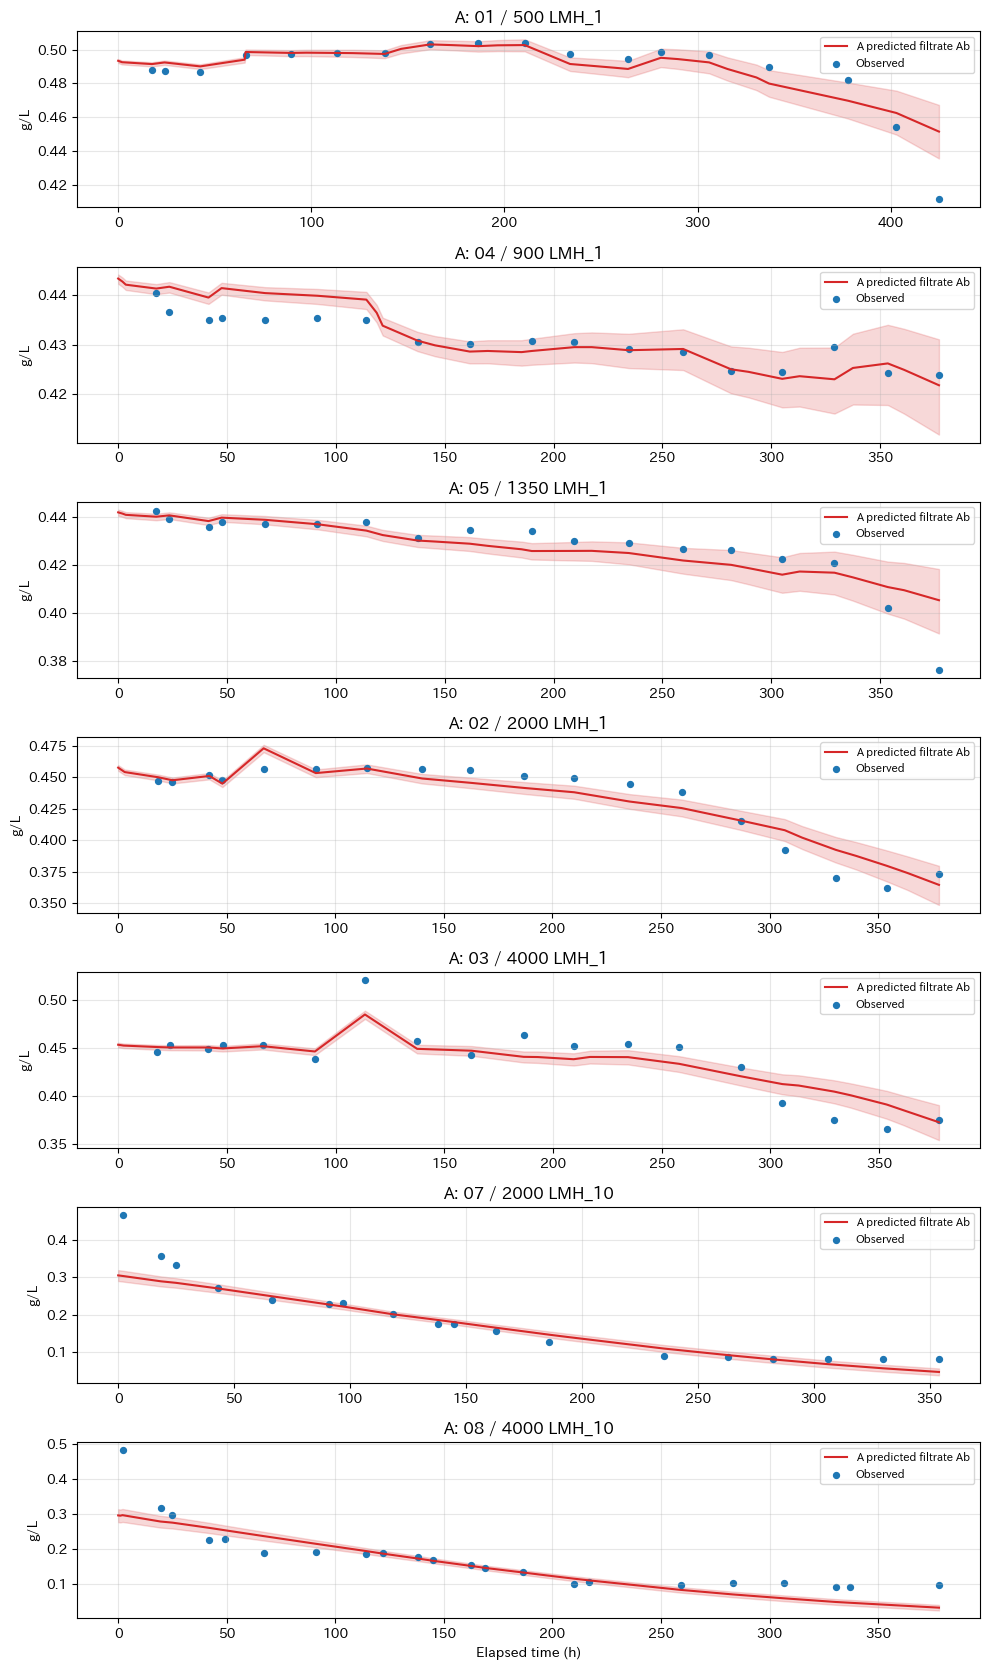

Saved: d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results\akls_historical_ssm_A_filtrate_antibody.png


In [ ]:
# このセルでは、案Aの事後予測をCSVへ保存し、filtrate抗体濃度の診断図をrun別に作成する。
if idata_A is not None:
    # 事後分布から、effective sieving・filtrate抗体濃度予測・累積劣化量の平均とHDI区間を付与する
    pred_A = summarize_predictions(
        idata_A,
        ["effective_sieving_fraction", "filtrate_antibody_pred_g_l", "degradation_state"],
        data["df"],
        prefix="A",
    )
    pred_A_path = OUTPUT_DIR / "akls_historical_ssm_A_predictions.csv"
    pred_A.to_csv(pred_A_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {pred_A_path}")
    display(pred_A.head())

    # run別に1段ずつグラフを並べ、予測平均±区間（赤）と実測値（青の散布図）を重ねて診断する
    fig, axes = plt.subplots(len(data["runs"]), 1, figsize=(10, max(3, 2.4 * len(data["runs"]))), sharex=False)
    if len(data["runs"]) == 1:
        axes = [axes]
    for ax, run in zip(axes, data["runs"]):
        mask = pred_A["run_id"].eq(run)
        sub = pred_A.loc[mask]
        x = sub["elapsed_h"].to_numpy(float)
        ax.plot(x, sub["A_filtrate_antibody_pred_g_l_mean"], color="#D62728", label="A predicted filtrate Ab")
        ax.fill_between(x, sub["A_filtrate_antibody_pred_g_l_lower"], sub["A_filtrate_antibody_pred_g_l_upper"], color="#D62728", alpha=0.18)
        obs = sub["filtrate_antibody_g_l"].notna()
        ax.scatter(sub.loc[obs, "elapsed_h"], sub.loc[obs, "filtrate_antibody_g_l"], s=18, color="#1F77B4", label="Observed")
        ax.set_title(f"A: {run} / {sub['condition_label'].iloc[0] if 'condition_label' in sub else ''}")
        ax.set_ylabel("g/L")
        ax.grid(alpha=0.6)
        ax.legend(fontsize=8)
    axes[-1].set_xlabel("Elapsed time (h)")
    fig.tight_layout()
    plot_A_path = OUTPUT_DIR / "akls_historical_ssm_A_filtrate_antibody.png"
    fig.savefig(plot_A_path, dpi=180)
    plt.show()
    print(f"Saved: {plot_A_path}")
else:
    print("idata_A is None. 案Aの事後予測出力はスキップしました。")


## 5. 案B: Cumulative recovery / quality SSM

案Bは案Aの `S_t` に相当するeffective sievingを使い、累積回収状態 `Q_t` を構成する。案Aが「その瞬間の濃度」を予測するのに対し、案Bは「濾過開始から今までにどれだけの抗体を回収できたか」という累積量を予測する点が異なる。

### 状態

```text
Q_t = cumulative recovered antibody proxy, roughly g/m2
```

### 状態方程式

```text
Q_t = Q_{t-1} + feed_mid * S_t * delta_cumulative_filtrate_l_m2 * recovery_scale
```

### 観測方程式

1. 途中のfiltrate antibody濃度:

```text
filtrate_antibody_obs_t ~ feed_antibody_t * S_t
```

2. final cumulative recovery proxyが利用可能な場合:

```text
final_recovery_obs_run ~ Q_T_run
```

最終累積回収量が実測列として存在しない場合、このNotebookではfiltrate抗体濃度と累積ろ過量からproxyを作る。これは独立観測ではなく診断的な目安である。

次のコードセルでモデルを構築・推定し、その次のセルで濃度・累積回収量の両方をグラフ化する。


In [ ]:
# このセルでは、案Bの累積回収・品質状態空間モデルを構築し、サンプリング結果を保存する。
def build_model_B_cumulative_recovery(data: dict):
    if not PYMC_AVAILABLE:
        raise RuntimeError("PyMC is not available.")
    n_runs = len(data["runs"])
    to_obs = data["transition_df"]["to_obs"].to_numpy(int)
    with pm.Model() as model:
        A = pm.Data("A_hist", data["A_hist"])
        dt_days = pm.Data("dt_days", data["dt_days"])
        delta_cum = pm.Data("delta_cum_l_m2", data["delta_cum_l_m2"])
        F_mid_reported = pm.Data("F_mid_std_reported", data["F_mid_std"])
        F_mid_sigma = pm.Data("F_mid_sigma_std", data["F_mid_sigma_std"])
        tmp_mid_reported = pm.Data("tmp_mid_std_reported", data["tmp_mid_std"])
        tmp_mid_sigma = pm.Data("tmp_mid_sigma_std", data["tmp_mid_sigma_std"])
        high_load = pm.Data("high_load_transition", data["high_load_transition"])
        feed_mid = pm.Data("feed_mid", data["feed_mid"])
        feed_obs = pm.Data("feed_obs", data["feed_obs"])
        run_idx_obs = pm.Data("run_idx_obs", data["run_idx_obs"])

        # 案Aと同じ測定誤差モデル。前段のfouling/TMP予測を潜在変数として扱う。
        if USE_PROPAGATION_UNCERTAINTY:
            F_mid = pm.Normal("F_mid_std_latent", mu=F_mid_reported, sigma=pt.maximum(F_mid_sigma, 1e-3))
            tmp_mid = pm.Normal("tmp_mid_std_latent", mu=tmp_mid_reported, sigma=pt.maximum(tmp_mid_sigma, 1e-3))
        else:
            F_mid = F_mid_reported
            tmp_mid = tmp_mid_reported

        # ここまでは案Aと同じeffective sievingの状態方程式（劣化がsievingを下げるという構造）
        z0 = pm.Normal("z0_logit_sieving", mu=4.0, sigma=1.0, shape=n_runs)
        theta0 = pm.Normal("theta0_log_degradation_rate", mu=-3.0, sigma=1.2)
        theta_F = pm.HalfNormal("theta_fouling", sigma=0.7)
        theta_tmp = pm.HalfNormal("theta_tmp", sigma=0.7)
        theta_high = pm.HalfNormal("theta_high_load", sigma=0.8)

        log_rate = theta0 + theta_F * F_mid + theta_tmp * tmp_mid + theta_high * high_load
        degradation_increments = pm.Deterministic("degradation_increments", pm.math.exp(log_rate) * dt_days)
        degradation_state = pm.Deterministic("degradation_state", pm.math.dot(A, degradation_increments))

        z = pm.Deterministic("z_sieving_logit", z0[run_idx_obs] - degradation_state)
        S = pm.Deterministic("effective_sieving_fraction", pm.math.sigmoid(z))
        filtrate_mu = pm.Deterministic("filtrate_antibody_pred_g_l", feed_obs * S)

        # 累積回収量側。各遷移で「その区間に回収された抗体量」= 遷移先時点のS x feed x 累積ろ過量の増分、として計算し、
        # A_hist行列で積み上げることで各観測時点の累積回収状態Qを求める。recovery_scaleは実測とのスケール調整項。
        recovery_scale = pm.LogNormal("recovery_scale", mu=0.0, sigma=0.25)
        q_increments = pm.Deterministic("quality_recovery_increments_g_m2", recovery_scale * feed_mid * S[to_obs] * delta_cum)
        Q = pm.Deterministic("quality_recovery_state_g_m2", pm.math.dot(A, q_increments))

        # 観測1: 途中のfiltrate抗体濃度（案Aと同じ尤度）
        sigma_filtrate = pm.HalfNormal("sigma_filtrate_antibody_g_l", sigma=0.08)
        idx = data["filtrate_obs_idx"]
        pm.StudentT(
            "filtrate_antibody_obs",
            nu=4,
            mu=filtrate_mu[idx],
            sigma=sigma_filtrate,
            observed=data["filtrate_antibody_obs"],
        )

        # 観測2（任意）: run最終時点の累積回収量proxyを、Qの最終値に紐づけて尤度に加える
        if USE_FINAL_CUMULATIVE_RECOVERY_LIKELIHOOD and len(data["final_recovery_idx"]):
            sigma_recovery = pm.HalfNormal("sigma_final_recovery_g_m2", sigma=max(np.nanstd(data["final_recovery_obs"]), 0.05))
            ridx = data["final_recovery_idx"]
            pm.StudentT(
                "final_recovery_obs",
                nu=4,
                mu=Q[ridx],
                sigma=sigma_recovery,
                observed=data["final_recovery_obs"],
            )

    return model

idata_B = None
model_B = None
if RUN_MODEL_B and PYMC_AVAILABLE:
    model_B = build_model_B_cumulative_recovery(data)
    print(model_B.initial_point())
    if RUN_SAMPLING:
        with model_B:
            idata_B = pm.sample(**sample_kwargs())
        path_B = OUTPUT_DIR / "akls_historical_ssm_B_cumulative_recovery_idata.nc"
        az.to_netcdf(idata_B, path_B)
        print(f"Saved: {path_B}")
        vars_B = ["theta0_log_degradation_rate", "theta_fouling", "theta_tmp", "theta_high_load", "recovery_scale", "sigma_filtrate_antibody_g_l"]
        if USE_FINAL_CUMULATIVE_RECOVERY_LIKELIHOOD and len(data["final_recovery_idx"]):
            vars_B.append("sigma_final_recovery_g_m2")
        display(az.summary(idata_B, var_names=vars_B, hdi_prob=HDI_PROB))
elif RUN_MODEL_B:
    print("PyMCが使えないため、案Bモデル構築/サンプリングをスキップしました。")


{'z0_logit_sieving': array([4., 4., 4., 4., 4., 4., 4.]), 'theta0_log_degradation_rate': array(-3.), 'theta_fouling_log__': array(-0.3567), 'theta_tmp_log__': array(-0.3567), 'theta_high_load_log__': array(-0.2231), 'recovery_scale_log__': array(0.0312), 'sigma_filtrate_antibody_g_l_log__': array(-2.5257), 'sigma_final_recovery_g_m2_log__': array(3.5049)}


  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

Saved: d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results\akls_historical_ssm_B_cumulative_recovery_idata.nc


,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta0_log_degradation_rate,-1.741,0.070,-1.854,-1.622,0.002,0.001,905.0,1321.0,1.0
theta_fouling,0.061,0.051,0.000,0.131,0.001,0.001,1537.0,1508.0,1.0
theta_tmp,0.039,0.033,0.000,0.086,0.001,0.001,1479.0,1597.0,1.0
theta_high_load,0.047,0.044,0.000,0.107,0.001,0.001,1622.0,1341.0,1.0
recovery_scale,1.018,0.030,0.975,1.070,0.001,0.001,1939.0,1464.0,1.0
sigma_filtrate_antibody_g_l,0.012,0.001,0.010,0.014,0.000,0.000,2149.0,2004.0,1.0
sigma_final_recovery_g_m2,10.552,5.248,3.200,17.417,0.121,0.169,1999.0,2169.0,1.0


Saved: d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results\akls_historical_ssm_B_predictions.csv


,run_id,record_id,source_file,source_sheet,condition_label,shear_rate_lmh,lmh_group,row_number,sample_label,elapsed_h,sampling_volume_raw,sample_volume_feed_ml,sample_volume_filtrate_ml,circulation_flow_ml_min,circulation_pump_rpm,filtration_flow_ul_min,filtrate_column_cm,filtrate_collection_time_raw,cumulative_filtrate_l_m2,cumulative_flow_ratio_pct,filtration_flow_ratio_pct,pressure_in_kpa,pressure_out_kpa,back_pressure_kpa,tmp_kpa,temperature_c,vcd_cho_1e5_cells_ml,viability_cho_pct,vcd_matsuda_1e5_cells_ml,viability_matsuda_pct,glc_g_l,glu_mmol_l,gln_mmol_l,lln_g_l,feed_antibody_g_l,filtrate_antibody_g_l,transmission_pct,feed_ab_amount_g_m2,filtrate_ab_amount_g_m2,cumulative_transmission_pct,turbidity_feed_od600,turbidity_filtrate_od600,turbidity_plate_reader_od600,ldh_reading_1,ldh_reading_2,ldh_avg,ldh_sd,is_before_start,is_filtration_start,time_from_previous_h,tmp_delta_from_start_kpa,transmission_delta_from_start_pct,filtrate_ab_ratio_to_start,fouling_indicator_simple,cumulative_filtrate_l_m2_interp,back_pressure_kpa_interp,back_pressure_load,feed_antibody_g_l_interp,run_idx,fouling_state_mean,fouling_state_lower,fouling_state_upper,tmp_pred_kpa_mean,tmp_pred_kpa_lower,tmp_pred_kpa_upper,transmission_pred_pct_mean,transmission_pred_pct_lower,transmission_pred_pct_upper,filtrate_antibody_pred_g_l_mean,filtrate_antibody_pred_g_l_lower,filtrate_antibody_pred_g_l_upper,data_source,feed_antibody_interp,filtrate_antibody_interp,fouling_state_interp,tmp_pred_interp,transmission_obs_fraction,high_load,cumulative_filtrate_interp,observed_cum_recovery_g_m2_proxy,B_effective_sieving_fraction_mean,B_effective_sieving_fraction_lower,B_effective_sieving_fraction_upper,B_filtrate_antibody_pred_g_l_mean,B_filtrate_antibody_pred_g_l_lower,B_filtrate_antibody_pred_g_l_upper,B_quality_recovery_state_g_m2_mean,B_quality_recovery_state_g_m2_lower,B_quality_recovery_state_g_m2_upper,B_degradation_state_mean,B_degradation_state_lower,B_degradation_state_upper
0,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,5,Filtration start,0.0,NaN,NaN,NaN,8.05,920.0,NaN,NaN,NaN,0.000000,NaN,NaN,1.5,-1.0,-0.4,0.7,9.4,146.0,94.8,NaN,NaN,3.14,0.48,0.32,0.50,0.496091,NaN,NaN,NaN,NaN,NaN,1.225,NaN,NaN,NaN,NaN,NaN,NaN,0,1,NaN,0.0,NaN,NaN,0.000000,0.000000,-0.4,0.4,0.496091,0,0.000000,0.000000,0.000000,0.483935,0.455199,0.512434,98.960754,98.732175,99.170439,0.490935,0.489801,0.491975,propagation_predictions,0.496091,0.488015,0.000000,0.483935,NaN,0.0,0.000000,0.000000,0.994505,0.991862,0.996540,0.493365,0.492053,0.494374,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,6,NaN,2.0,NaN,NaN,NaN,8.05,950.0,NaN,NaN,NaN,NaN,NaN,NaN,1.3,-1.3,-0.8,0.8,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,2.0,0.1,NaN,NaN,0.001000,8.943885,-0.8,0.8,0.495266,0,0.003431,0.001270,0.007652,0.884225,0.855476,0.912711,98.957863,98.728804,99.166979,0.490105,0.488970,0.491141,propagation_predictions,0.495266,0.488015,0.003431,0.884225,NaN,0.0,8.943885,4.364747,0.994434,0.991774,0.996489,0.492510,0.491192,0.493527,4.487692,4.290506,4.710313,0.013153,0.010636,0.015355
2,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,7,NaN,17.5,NaN,NaN,NaN,8.05,960.0,5.110792,2.3,00:33:58,17.887771,101.693805,NaN,1.4,-1.3,-1.0,1.1,3.6,137.0,93.5,NaN,NaN,3.16,0.50,0.28,0.56,0.494442,0.488015,98.700124,8.859209,8.729494,98.535814,NaN,0.006,NaN,NaN,NaN,NaN,NaN,0,0,15.5,0.4,0.000000,1.000000,0.004000,17.887771,-1.0,1.0,0.494442,0,0.030445,0.011430,0.067589,1.085371,1.057079,1.113444,98.933842,98.707957,99.140203,0.489170,0.488053,0.490191,propagation_predictions,0.494442,0.488015,0.030445,1.085371,0.987001,0.0,17.887771,8.729494,0.993850,0.991027,0.996069,0.491401,0.490005,0.492498,8.965285,8.570717,9.409610,0.115373,0.093653,0.134508
3,01,1,02-01_Perfusion-shear_rate_500_LMH_1.xlsx,01-record,500 LMH_1,500,1,8,NaN,24.0,NaN,NaN,NaN,8.05,

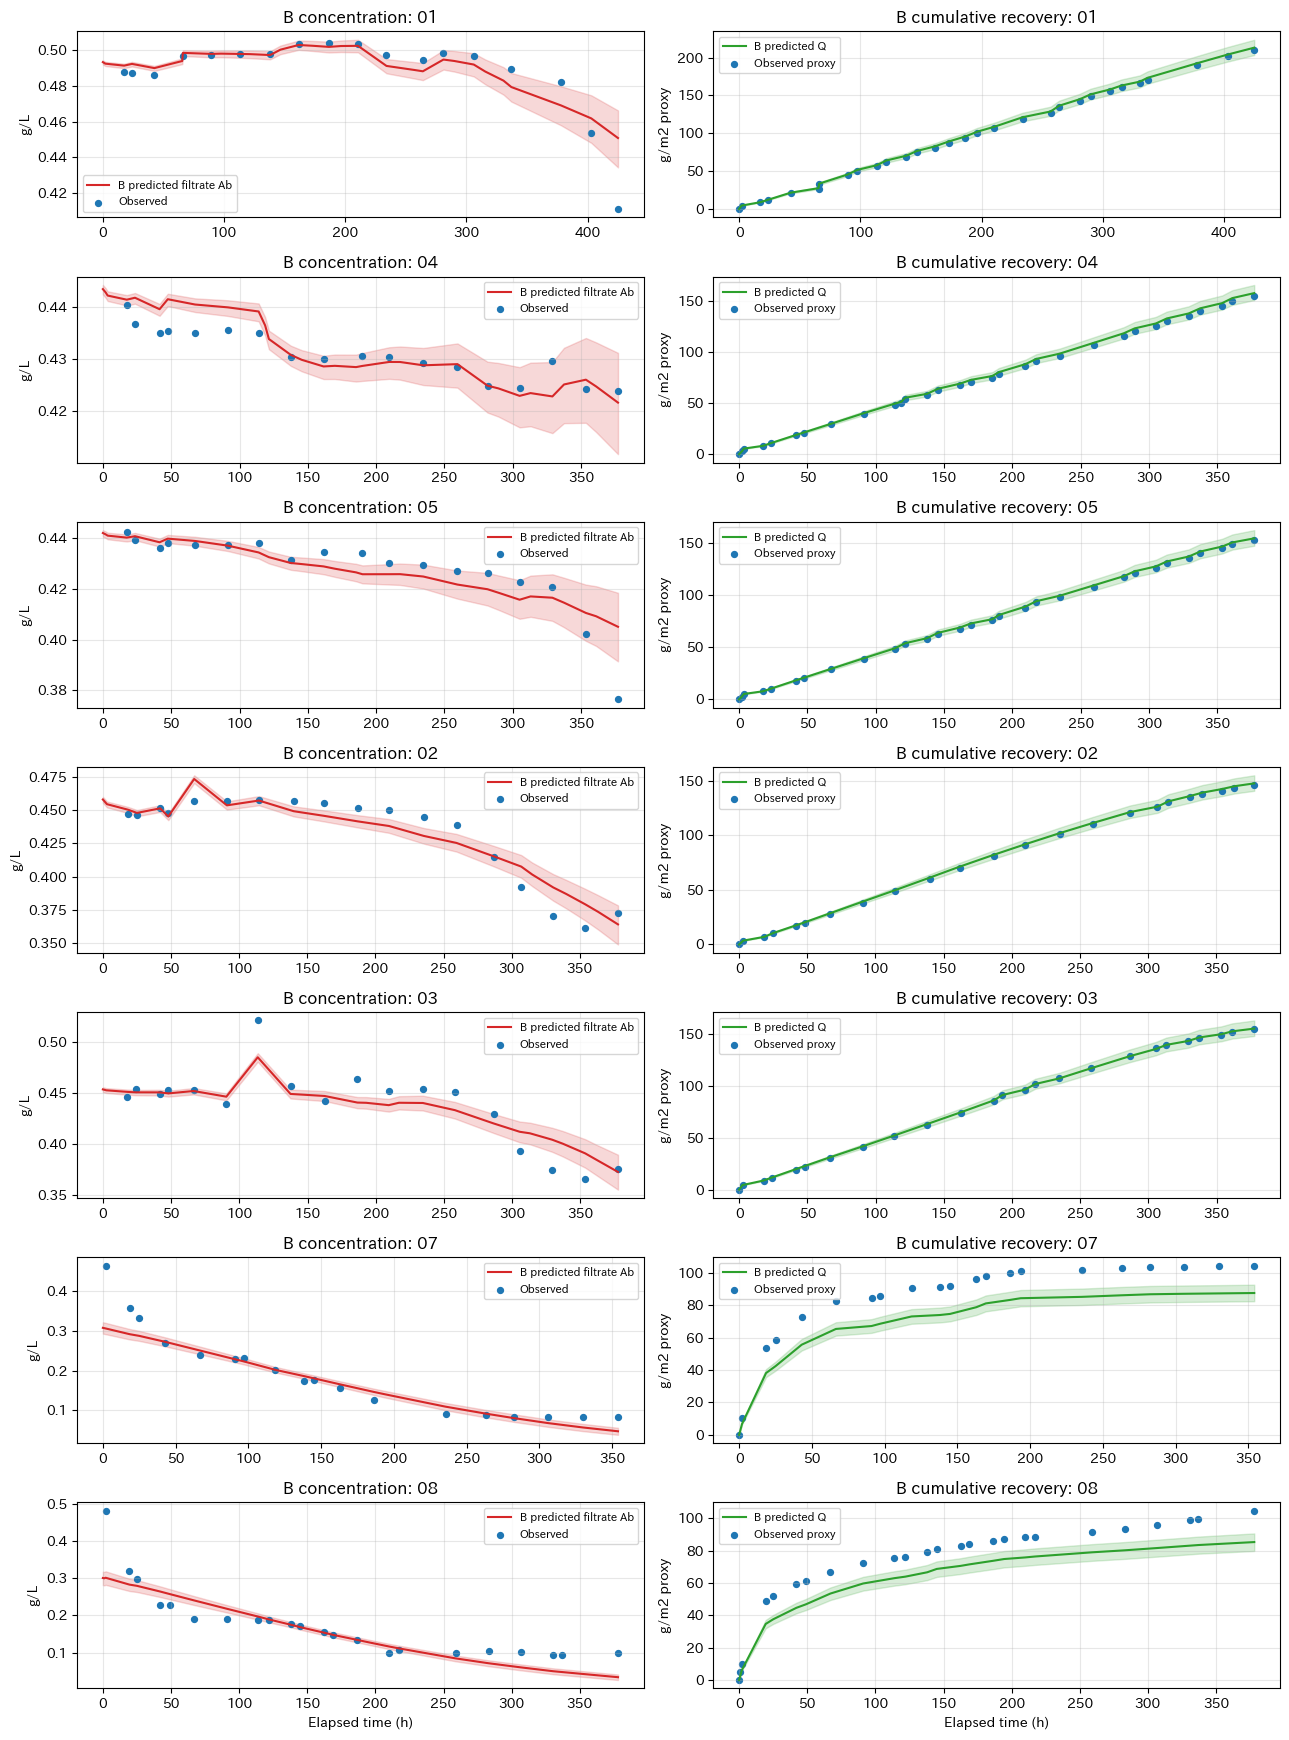

Saved: d:\Users\a1049994\CVC\AKLS\akls_historical_ssm_auxiliary_results\akls_historical_ssm_B_filtrate_and_recovery.png


In [ ]:
# このセルでは、案Bの事後予測をCSVへ保存し、濃度と累積回収量の診断図を作成する。
if idata_B is not None:
    pred_B = summarize_predictions(
        idata_B,
        ["effective_sieving_fraction", "filtrate_antibody_pred_g_l", "quality_recovery_state_g_m2", "degradation_state"],
        data["df"],
        prefix="B",
    )
    pred_B_path = OUTPUT_DIR / "akls_historical_ssm_B_predictions.csv"
    pred_B.to_csv(pred_B_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {pred_B_path}")
    display(pred_B.head())

    # run別に2列（左:濃度、右:累積回収量）のグラフを並べ、予測平均±区間と実測/proxyを比較する
    fig, axes = plt.subplots(len(data["runs"]), 2, figsize=(13, max(3, 2.5 * len(data["runs"]))), sharex=False)
    if len(data["runs"]) == 1:
        axes = np.asarray([axes])
    for row_axes, run in zip(axes, data["runs"]):
        mask = pred_B["run_id"].eq(run)
        sub = pred_B.loc[mask]
        x = sub["elapsed_h"].to_numpy(float)

        ax = row_axes[0]
        ax.plot(x, sub["B_filtrate_antibody_pred_g_l_mean"], color="#D62728", label="B predicted filtrate Ab")
        ax.fill_between(x, sub["B_filtrate_antibody_pred_g_l_lower"], sub["B_filtrate_antibody_pred_g_l_upper"], color="#D62728", alpha=0.18)
        obs = sub["filtrate_antibody_g_l"].notna()
        ax.scatter(sub.loc[obs, "elapsed_h"], sub.loc[obs, "filtrate_antibody_g_l"], s=18, color="#1F77B4", label="Observed")
        ax.set_title(f"B concentration: {run}")
        ax.set_ylabel("g/L")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

        ax = row_axes[1]
        ax.plot(x, sub["B_quality_recovery_state_g_m2_mean"], color="#2CA02C", label="B predicted Q")
        ax.fill_between(x, sub["B_quality_recovery_state_g_m2_lower"], sub["B_quality_recovery_state_g_m2_upper"], color="#2CA02C", alpha=0.18)
        if "observed_cum_recovery_g_m2_proxy" in sub.columns:
            ax.scatter(x, sub["observed_cum_recovery_g_m2_proxy"], s=18, color="#1F77B4", label="Observed proxy")
        ax.set_title(f"B cumulative recovery: {run}")
        ax.set_ylabel("g/m2 proxy")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    axes[-1, 0].set_xlabel("Elapsed time (h)")
    axes[-1, 1].set_xlabel("Elapsed time (h)")
    fig.tight_layout()
    plot_B_path = OUTPUT_DIR / "akls_historical_ssm_B_filtrate_and_recovery.png"
    fig.savefig(plot_B_path, dpi=180)
    plt.show()
    print(f"Saved: {plot_B_path}")
else:
    print("idata_B is None. 案Bの事後予測出力はスキップしました。")


## 6. 案Aと案Bの使い分け

### 案Aが向くケース

- 目的が `filtrate antibody concentration` の時系列/最終値
- `filtrate antibody = feed antibody * effective sieving` の関係を重視したい
- Transmissionとfiltrate antibodyの二重カウントを避けたい
- 最初のHistorical SSMとして堅く始めたい

### 案Bが向くケース

- 目的が濃度だけでなく、累積回収量・累積透過量・product recoveryに近い
- `cumulative_filtrate_l_m2` を使って、時間積分された品質/回収状態を作りたい
- 最終Yを濃度ではなく累積量として評価したい

### 注意

- 案Bの `observed_cum_recovery_g_m2_proxy` は、実測累積回収量ではなく、filtrate antibody濃度と累積ろ過量から作ったproxyである。
- 実測の累積product recoveryや累積filtrate antibody amountが別途あるなら、その列を使うように `build_hist_ssm_arrays()` を拡張する。
- Transmission観測を案A/Bの尤度に追加する場合は、filtrate antibodyから計算された値との二重カウントに注意する。